# 自旋极化度标定 — Pump-off FID MORS 法

**实验目的**：CW Pump 建立稳态极化 → 关断 Pump → 极化自由进动 →
FID 的 FFT 频谱中各塞曼分量分离 → 多峰拟合得 ρ_{m,m} → 极化度 P。

**原理**：
- CW Pump (X) 建立稳态极化 P₀ = (1/F) Σ m ρ_{m,m}
- Pump 关断后，各 Zeeman 相干以 ν_L(m) = ν_L + ν_s·(m+1/2) 独立进动
- Probe Faraday 旋光探测总横向自旋 S_x(t) = Σ w_m cos(ν_L(m)·t) exp(-t/T₂*)
- LIA (ref=ν_L) 解调得差频信号，DAQ 采集 X/Y → 复信号 X+iY
- FFT 得各 ν_s·(m+1/2) 处的峰 → 相对幅度 = w_m ∝ [ρ_{m+1} - ρ_m]
- 外推包络到 t=0 修正 T₁ 衰减

**Pump-off 期间的极化衰减修正**：
- T₁ ≈ 30 ms，FID 采集 10 ms → 极化降至 exp(-10/30) ≈ 72%
- FID 包络 A(t) = A₀ exp(-t/T₂*) 反映的是横向弛豫（~1.8 ms）
- 各塞曼分量的相对布居在 T₁ 时间尺度上均匀衰减 → 不影响 P 的提取
- 如需绝对 P：FID 初值 × exp(+t_acq/(2T₁)) 修正

**与 v1/v2 的本质区别**：

| | v1: CW+RF | v2: Bell-Bloom | v3: Pump-off FID (本实验) |
|---|---|---|---|
| **Pump 状态** | CW | 脉冲同步 | CW 建立 → 关断 |
| **激发方式** | RF 线圈 | Pump 调制 | 自然进动 (无需 RF) |
| **塞曼相干** | 被 Pump 消相干 | 被同步锁定 | 自由独立进动 |
| **多峰可见？** | 否 (SNR 太差) | 否 (机理抑制) | **应可见** |
| **信号强度** | ~μV | ~1V | **~1V** (与 v2 同级) |

**涉及设备**：
- GS200：主磁场
- DG912 Pro：Pump 光功率 (CH1 DC)、Probe 光功率 (CH2 DC)
- DG4000 (#1 调制)：Pump_modulation CH1=100MHz CW + Time_sequence CH2=脉冲门控
- DG4000 (#2 温控)：温度开关 CH2
- HF2：锁相放大器 (ref=ν_L) + DAQ 采集 X/Y 时间序列
- TEC103：气室温度控制

In [20]:
# ========== 交互式绘图模式 ==========
%matplotlib widget

from pathlib import Path
import sys
project_root = Path.cwd()
while not (project_root / "params").exists() and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import yaml
import time
from datetime import datetime
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import curve_fit
from scipy import signal as scipy_signal

# 设备库
from gs200 import GS200Instrument
from signal_generator import DG4000Instrument, DG900Instrument
from tec_controller import TECInstrument
from lockin_amplifier import (
    HF2Instrument, DAQConfig, DemodulatorConfig,
    demod, daq,
)

print("所有库导入成功")

所有库导入成功


In [21]:
# ========== 加载配置 ==========

with open(project_root / "params" / "mapping.yaml", encoding="utf-8") as f:
    MAPPING = yaml.safe_load(f)["mapping"]
with open(project_root / "params" / "safety_limits.yaml", encoding="utf-8") as f:
    LIMITS = yaml.safe_load(f)["safety_limits"]

# ========== 物理常数 ==========
GYRO_RATIO = 700e3          # 87Rb F=2 旋磁比 (Hz/G)
NU_HFS = 6.835e9            # 87Rb 基态超精细分裂 (Hz)
COIL_CONSTANT = 9670.0      # Hz/mA
NU_RESIDUAL = 0.0           # Hz

# ========== 实验参数 ==========
EXPERIMENT_TYPE = "MORS_polarization_pulsed"
PURPOSE = "polarization_calibration_fid"

# ---- Pump / Probe 光功率 ----
PUMP_POWER = 0.1
PROBE_POWER = 0.1

# ---- 主磁场扫描 ----
B_CURRENT_mA = np.array([50.0, 70.0, 90.0])

# ---- Pump 调制 ----
PUMP_MOD_AMPLITUDE = 0.18      # 100MHz CW 载波 (V)
PUMP_MOD_FREQ = 100e6

# CH2: Bell-Bloom 共振泵浦 — 方波脉冲串 @ ν_L, Burst 模式
TIME_SEQ_AMPLITUDE = 5.0       # Vpp
TIME_SEQ_OFFSET = 2.5          # DC 偏置 → 0/5V 逻辑
TIME_SEQ_DUTY = 5.0            # Bell-Bloom 低占空比 (%)
BURST_N_CYCLES = 50000         # 每串脉冲数 (DG4000 上限)
FID_DURATION = 0.010           # FID 采集时长 (s)
CYCLE_MARGIN = 0.005           # 脉冲串间额外等待 (s)

# ---- LIA 参数 ----
HF2_DEMOD_IDX = 0
HF2_SIGNAL_RANGE = 2.0
HF2_DEMOD_ORDER = 4
HF2_DEMOD_TC = 3e-6            # 尽量小, 避免 LIA 滤波畸变 FID
HF2_DEMOD_RATE = 115000

# ---- 温度 ----
TEC_TEMPERATURE = 100.0
TEMP_SW_V = 5.0

# ---- FID 重复 ----
FID_REPEATS = 10

# ========== 运行目录 ==========
RUN_TAG = "polarization_fid_burst"

def validate_safety_limit(name, value):
    lim = LIMITS.get(name)
    if lim is None:
        return value
    lo, hi = lim["min"], lim["max"]
    if value is not None and (value < lo or value > hi):
        raise ValueError(f"[安全拦截] {name}={value} 超出范围 [{lo}, {hi}]")
    return value

for i_ma in B_CURRENT_mA:
    validate_safety_limit("main_magnetic_field", float(i_ma))

def calc_nu_L(I_mA):
    return COIL_CONSTANT * I_mA + NU_RESIDUAL

def calc_burst_params(nu_L):
    """根据 ν_L 计算 Burst 参数"""
    burst_dur = BURST_N_CYCLES / nu_L       # 泵浦串时长 (s)
    burst_period = burst_dur + FID_DURATION + CYCLE_MARGIN
    burst_freq = 1.0 / burst_period
    return burst_dur, burst_period, burst_freq

print("配置加载完成")
print(f"  B 扫描: {B_CURRENT_mA} mA")
print(f"  nu_L 范围: {calc_nu_L(B_CURRENT_mA[0])/1000:.1f} ~ {calc_nu_L(B_CURRENT_mA[-1])/1000:.1f} kHz")
for I in B_CURRENT_mA:
    nu = calc_nu_L(I)
    bd, bp, bf = calc_burst_params(nu)
    print(f"    {I:.0f}mA: nu_L={nu/1000:.1f}k, burst={bd*1000:.0f}ms ON + {FID_DURATION*1000:.0f}ms OFF, period={bp*1000:.0f}ms ({bf:.1f}Hz)")
print(f"  FID: {FID_DURATION*1000:.0f} ms x {FID_REPEATS} 次")
print(f"  DAQ 触发: DG4000 CH2 Sync 下降沿 → HF2 AuxIn0")

配置加载完成
  B 扫描: [50. 70. 90.] mA
  nu_L 范围: 483.5 ~ 870.3 kHz
    50mA: nu_L=483.5k, burst=103ms ON + 10ms OFF, period=118ms (8.4Hz)
    70mA: nu_L=676.9k, burst=74ms ON + 10ms OFF, period=89ms (11.3Hz)
    90mA: nu_L=870.3k, burst=57ms ON + 10ms OFF, period=72ms (13.8Hz)
  FID: 10 ms x 10 次
  DAQ 触发: DG4000 CH2 Sync 下降沿 → HF2 AuxIn0


In [22]:
# ========== 连接设备 ==========

devices = {}

try:
    # ---- GS200: 主磁场 ----
    gs_cfg = MAPPING["main_magnetic_field"]
    gs = GS200Instrument(gs_cfg["resource"])
    gs.connect()
    print(f"GS200 已连接: {gs.idn()}")
    gs.set_source_function(gs_cfg["source_function"])
    gs.set_current_limit(LIMITS["main_magnetic_field"]["max"] / 1000.0)
    devices["gs200"] = gs

    # ---- DG912 Pro: Pump/Probe 光功率 (DC) ----
    dg_laser_cfg = MAPPING["Pump_laser_power"]
    dg_laser = DG900Instrument(dg_laser_cfg["resource"], channel=1)
    dg_laser.connect()
    print(f"光功率 DG912 Pro 已连接: {dg_laser.idn()}")
    dg_laser.set_ref_clock_source("EXTernal")
    devices["dg_laser"] = dg_laser

    # ---- DG4000: 调制 (CH1=100MHz CW, CH2=脉冲门控) ----
    mod_cfg = MAPPING["Pump_modulation"]
    dg_mod = DG4000Instrument(mod_cfg["resource"], channel=mod_cfg["channel"])
    dg_mod.connect()
    print(f"调制 DG4000 已连接: {dg_mod.idn()}")
    devices["dg_mod"] = dg_mod

    # ---- DG4000: 温控 (温度开关 CH2) ----
    temp_sw_cfg = MAPPING["Temp_Switch"]
    dg_temp = DG4000Instrument(temp_sw_cfg["resource"], channel=temp_sw_cfg["channel"])
    dg_temp.connect()
    print(f"温控 DG4000 已连接: {dg_temp.idn()}")
    devices["dg_temp"] = dg_temp

    # ---- TEC103: 温度控制器 ----
    tec_cfg = MAPPING["temperature"]
    tec = TECInstrument(port=tec_cfg["resource"])
    tec.connect()
    print(f"TEC103 已连接")
    devices["tec"] = tec

    # ---- HF2: 锁相放大器 ----
    hf2_cfg = MAPPING["lockin_r"]
    hfi = HF2Instrument(
        host=hf2_cfg.get("host", "127.0.0.1"),
        port=hf2_cfg.get("port", 8005),
        api_level=1,
        device_id=hf2_cfg["device_id"],
    )
    hfi.connect()
    print(f"HF2 已连接: {hfi.idn}")
    hfi.set_extclk(True)
    devices["hf2"] = hfi

except Exception as e:
    print(f"设备连接失败: {e}")
    raise

print(f"\n所有设备连接完成，共 {len(devices)} 个设备")

GS200 已连接: YOKOGAWA,GS210,90Z631552,2.02
光功率 DG912 Pro 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q280100002,00.02.01.00.02
调制 DG4000 已连接: Rigol Technologies,DG4162,DG4E222800868,00.01.14
温控 DG4000 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q271200104,00.02.00.00.05
TEC103 已连接
HF2 已连接: HF2LI

所有设备连接完成，共 6 个设备


In [23]:
# ========== 设置初始值并创建运行目录 ==========

# ---- 1. Pump 光功率 (DC) ----
validate_safety_limit("Pump_laser_power", PUMP_POWER)
dg_laser.setup_dc(PUMP_POWER, channel=1)
dg_laser.set_output(True, channel=1)
print(f"Pump 光 DC: CH1={PUMP_POWER} V (ON)")

# ---- 2. Probe 光功率 (DC) ----
validate_safety_limit("Probe_laser_power", PROBE_POWER)
dg_laser.setup_dc(PROBE_POWER, channel=2)
dg_laser.set_output(True, channel=2)
print(f"Probe 光 DC: CH2={PROBE_POWER} V (ON)")

# ---- 3. Pump 调制 ----
# CH1: 100MHz CW 载波, 始终 ON
validate_safety_limit("Pump_modulation", PUMP_MOD_AMPLITUDE)
dg_mod.setup_sine(freq=PUMP_MOD_FREQ, amplitude=PUMP_MOD_AMPLITUDE,
                  offset=0.0, channel=1)
dg_mod.set_output(True, channel=1)
print(f"Pump 调制 CH1: {PUMP_MOD_FREQ/1e6:.0f} MHz, {PUMP_MOD_AMPLITUDE} Vpp (ON)")

# CH2: Bell-Bloom 共振 Burst 模式
# 方波 @ ν_L → 脉冲串 → 输出归零 → FID → 下一串
nu_L_init = calc_nu_L(B_CURRENT_mA[0])
burst_dur_init, burst_period_init, _ = calc_burst_params(nu_L_init)
validate_safety_limit("Time_sequence", TIME_SEQ_AMPLITUDE)

# 配置方波 @ ν_L
dg_mod.apply_wave("SQUare", channel=2, freq=nu_L_init,
                  amp=TIME_SEQ_AMPLITUDE, offset=TIME_SEQ_OFFSET)
dg_mod.set_square_dcycle(TIME_SEQ_DUTY, channel=2)

# Burst 模式: 每触发输出 N 周期, 内部定时触发
dg_mod.set_burst_state(True, channel=2)
dg_mod.set_burst_mode("TRIGgered", channel=2)
dg_mod.set_burst_ncycles(BURST_N_CYCLES, channel=2)
dg_mod.set_burst_trigger_source("INTernal", channel=2)
dg_mod.set_burst_period(burst_period_init, channel=2)

# Sync 输出 → DAQ 触发源
dg_mod.set_sync_state(True, channel=2)
dg_mod.set_sync_polarity("POSitive", channel=2)

dg_mod.set_output(True, channel=2)
print(f"Pump 调制 CH2: Burst 模式, {nu_L_init/1000:.1f} kHz 方波")
print(f"  每串 {BURST_N_CYCLES} 周期 ({burst_dur_init*1000:.0f}ms), 周期 {burst_period_init*1000:.0f}ms")
print(f"  Sync 输出: ON → HF2 AuxIn0")

# ---- 4. 温度开关 ----
validate_safety_limit("Temp_Switch", TEMP_SW_V)
dg_temp.setup_dc(TEMP_SW_V, channel=2)
dg_temp.set_output(True, channel=2)
print(f"温度开关: ON ({TEMP_SW_V} V)")

# ---- 5. 主磁场 ----
validate_safety_limit("main_magnetic_field", float(B_CURRENT_mA[0]))
gs.set_current(B_CURRENT_mA[0] / 1000.0)
gs.set_output(True)
print(f"主磁场: {B_CURRENT_mA[0]} mA")

# ---- 6. 温度控制 ----
validate_safety_limit("temperature", TEC_TEMPERATURE)
tec.set_target_temperature(TEC_TEMPERATURE, channel=1)
tec.set_enable(True, channel=1)
temp_now = tec.get_temperature(channel=1)
print(f"温度设定: {TEC_TEMPERATURE} C, 当前: {temp_now:.1f} C")
print("等待温度稳定...")
while True:
    time.sleep(5)
    t = tec.get_temperature(channel=1)
    print(f"  当前温度: {t:.2f} C")
    if abs(t - TEC_TEMPERATURE) < 1:
        print(f"温度已稳定: {t:.2f} C")
        break

# ---- 7. 配置 HF2 解调器 ----
demod.set_reference_frequency(hfi, nu_L_init, osc_idx=0)
demod_cfg = DemodulatorConfig(
    demod_index=HF2_DEMOD_IDX, enable=True,
    rate=HF2_DEMOD_RATE, input_channel=0,
    osc_select=0, harmonic=1,
    time_constant=HF2_DEMOD_TC, order=HF2_DEMOD_ORDER,
)
actual_rate = demod.configure_demodulator(hfi, demod_cfg)
print(f"HF2 解调器 {HF2_DEMOD_IDX}: Rate={actual_rate:.0f} Sa/s, TC={HF2_DEMOD_TC*1e6:.1f} us")
print(f"  参考频率: {nu_L_init/1000:.1f} kHz")

# ========== 创建运行目录 ==========
timestamp = datetime.now().strftime("%m%d_%H%M")
run_dir = project_root / "data" / EXPERIMENT_TYPE / f"{timestamp}_{RUN_TAG}"
run_dir.mkdir(parents=True, exist_ok=True)
raw_dir = run_dir / "raw"
raw_dir.mkdir(exist_ok=True)
results_dir = run_dir / "results"
results_dir.mkdir(exist_ok=True)
print(f"运行目录: {run_dir}")

# ========== 保存实验配置 ==========
config = {
    "experiment_type": EXPERIMENT_TYPE,
    "purpose": PURPOSE,
    "timestamp": timestamp,
    "method": "bell_bloom_burst_fid",
    "pump_scheme": "burst_mode_resonant",
    "constants": {
        "gyro_ratio_Hz_per_G": GYRO_RATIO,
        "nu_hfs_Hz": NU_HFS,
        "coil_constant_Hz_per_mA": COIL_CONSTANT,
    },
    "burst_params": {
        "n_cycles": BURST_N_CYCLES,
        "duty_pct": TIME_SEQ_DUTY,
        "fid_duration_s": FID_DURATION,
        "fid_repeats": FID_REPEATS,
        "cycle_margin_s": CYCLE_MARGIN,
    },
    "fixed_params": {
        "pump_power_V": PUMP_POWER,
        "probe_power_V": PROBE_POWER,
        "temperature_C": TEC_TEMPERATURE,
    },
    "trigger": {
        "source": "DG4000_CH2_Sync",
        "destination": "HF2_AuxIn0",
        "slope": "falling",
    },
}
config_path = run_dir / "experiment_config.yaml"
with open(config_path, "w", encoding="utf-8") as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)
print(f"实验配置已保存: {config_path}")

print("\n初始值设置完成")

Pump 光 DC: CH1=0.1 V (ON)
Probe 光 DC: CH2=0.1 V (ON)
Pump 调制 CH1: 100 MHz, 0.18 Vpp (ON)
Pump 调制 CH2: Burst 模式, 483.5 kHz 方波
  每串 50000 周期 (103ms), 周期 118ms
  Sync 输出: ON → HF2 AuxIn0
温度开关: ON (5.0 V)
主磁场: 50.0 mA
温度设定: 100.0 C, 当前: 101.6 C
等待温度稳定...
  当前温度: 101.05 C
  当前温度: 100.43 C
温度已稳定: 100.43 C
HF2 解调器 0: Rate=115132 Sa/s, TC=3.0 us
  参考频率: 483.5 kHz
运行目录: d:\Code\exp_agent\data\MORS_polarization_pulsed\0528_1727_polarization_fid_burst
实验配置已保存: d:\Code\exp_agent\data\MORS_polarization_pulsed\0528_1727_polarization_fid_burst\experiment_config.yaml

初始值设置完成


In [ ]:
# =====================================================================
# 主测量: Bell-Bloom Burst 泵浦 → Sync 触发 DAQ → FID 采集
#
# 接线: DG4000 CH2 输出 → RF 开关 CTRL (泵浦门控)
#       DG4000 CH2 Sync 输出 → HF2 AuxIn 0 (DAQ 触发)
#
# 时序: Burst 串 (ν_L 方波 × 50000) → 归零
#       Sync↑ (Burst 开始) → delay=burst_dur → DAQ 采 FID (Pump OFF)
# =====================================================================

print("=" * 60)
print("主测量: Burst 泵浦 + Sync 触发 + trigger_delay")
print(f"  B 扫描: {len(B_CURRENT_mA)} 个点")
print(f"  Burst: {BURST_N_CYCLES} cycles @ nu_L, 每 B 点 {FID_REPEATS} 次")
print(f"  触发: Sync ↑ → delay=burst_dur → DAQ 采 FID")
print("=" * 60)

all_results = []

try:
    for i_b, I_mA in enumerate(B_CURRENT_mA):
        nu_L = calc_nu_L(I_mA)
        nu_s_theory = nu_L**2 / (2 * NU_HFS)
        burst_dur, burst_period, burst_freq = calc_burst_params(nu_L)
        print(f"\n--- B {i_b+1}/{len(B_CURRENT_mA)}: I={I_mA:.1f} mA, nu_L={nu_L/1000:.1f} kHz ---")
        print(f"    Burst: {burst_dur*1000:.0f}ms ON, delay={burst_dur*1000:.0f}ms, period={burst_period*1000:.0f}ms")

        # ---- 设置主磁场 ----
        validate_safety_limit("main_magnetic_field", float(I_mA))
        gs.set_current(I_mA / 1000.0)
        time.sleep(0.5)

        # ---- 设置 HF2 参考频率 ----
        demod.set_reference_frequency(hfi, nu_L, osc_idx=0)
        time.sleep(0.1)

        # ---- 重配 CH2 Burst 参数 ----
        dg_mod.set_output(False, channel=2)
        dg_mod.apply_wave("SQUare", channel=2, freq=nu_L,
                          amp=TIME_SEQ_AMPLITUDE, offset=TIME_SEQ_OFFSET)
        dg_mod.set_square_dcycle(TIME_SEQ_DUTY, channel=2)
        dg_mod.set_burst_period(burst_period, channel=2)
        dg_mod.set_output(True, channel=2)
        time.sleep(0.3)

        # ---- DAQ 配置 ----
        grid_cols = int(actual_rate * FID_DURATION)
        print(f"    DAQ: {grid_cols} samples x {FID_REPEATS} reps")

        fid_waveforms_x = []
        fid_waveforms_y = []

        for rep in tqdm(range(FID_REPEATS), desc=f"  B={I_mA:.1f}mA FID", unit="rep", leave=False):
            # ---- 关闭温度开关 ----
            dg_temp.set_output(False, channel=2)
            time.sleep(0.2)

            daq_cfg = DAQConfig(
                device=MAPPING["lockin_r"]["device_id"],
                trigger_type=1,             # 边沿触发
                trigger_channel=0,           # AuxIn 0 ← CH2 Sync
                trigger_level=2.5,           # TTL 中点
                trigger_slope=0,             # 上升沿 = Burst 开始
                trigger_delay=burst_dur,     # 跳过整个 Burst → Pump OFF 时刻
                duration=FID_DURATION,
                grid_cols=grid_cols,
                grid_rows=1,
                grid_mode=2,
                signal_paths=["sample.x", "sample.y"],
            )

            try:
                results = daq.acquire_data(
                    hfi, daq_cfg, demod_idx=HF2_DEMOD_IDX,
                    actual_rate=actual_rate,
                    timeout=burst_period + FID_DURATION + 5.0,
                )
                if len(results) >= 2:
                    fid_waveforms_x.append(results[0].values)
                    fid_waveforms_y.append(results[1].values)
                elif len(results) == 1:
                    fid_waveforms_x.append(results[0].values)
                    fid_waveforms_y.append(np.full_like(results[0].values, np.nan))
            except Exception as e:
                tqdm.write(f"  [rep={rep}] DAQ error: {e}")
                fid_waveforms_x.append(np.full(grid_cols, np.nan))
                fid_waveforms_y.append(np.full(grid_cols, np.nan))

            # ---- 恢复温度开关 ----
            dg_temp.set_output(True, channel=2)
            time.sleep(2)

        # ---- 保存 ----
        x_arr = np.array(fid_waveforms_x)
        y_arr = np.array(fid_waveforms_y)
        t_axis = np.arange(grid_cols) / actual_rate

        np.savez(
            raw_dir / f"fid_I{I_mA:.1f}mA.npz",
            I_mA=I_mA, nu_L_theory_Hz=nu_L, nu_s_theory_Hz=nu_s_theory,
            time_axis_s=t_axis, actual_rate=actual_rate,
            fid_waveforms_x=x_arr, fid_waveforms_y=y_arr,
            fid_repeats=FID_REPEATS,
            burst_dur_s=burst_dur, burst_period_s=burst_period,
        )

        all_results.append({
            "I_mA": I_mA, "nu_L_theory_Hz": nu_L,
            "time": t_axis, "x_waveforms": x_arr, "y_waveforms": y_arr,
        })
        print(f"  -> 已保存, X 范围: [{np.nanmin(x_arr):.3e}, {np.nanmax(x_arr):.3e}] V")

except Exception as e:
    print(f"\n测量出错: {e}")
    try:
        dg_mod.set_output(False, channel=2)
        dg_temp.set_output(True, channel=2)
        gs.set_current(B_CURRENT_mA[0] / 1000.0)
    except Exception:
        pass
    raise

finally:
    dg_mod.set_output(False, channel=2)
    dg_temp.set_output(True, channel=2)
    print("CH2 输出已关闭，温度开关已恢复")

print(f"\n主测量完成，共 {len(all_results)} 个 B 点")

In [25]:
# =====================================================================
# 数据分析: FID → 复信号 → FFT → 塞曼峰 → 极化度
# =====================================================================

print("=" * 60)
print("FID 频谱分析")
print("=" * 60)

def analyze_fid(t_axis, x_wf, y_wf, nu_s_theory, nu_L):
    """
    对多次 FID 波形求平均 → 复信号 → FFT → 提取塞曼峰。
    返回: freqs, psd, fit_results
    """
    # 平均所有 repetitions
    x_mean = np.nanmean(x_wf, axis=0)
    y_mean = np.nanmean(y_wf, axis=0)

    # 复信号 Z = X + iY
    z = x_mean + 1j * y_mean

    # 去除 DC 偏置
    z = z - np.mean(z)

    # 加窗 (指数窗匹配 T2* 可优化 SNR, 这里仅用 Hanning 防止频谱泄漏)
    window = np.hanning(len(z))
    z_windowed = z * window

    # FFT, 零填充 4x 用于插值
    n_fft = len(z) * 4
    z_fft = np.fft.fftshift(np.fft.fft(z_windowed, n=n_fft))
    freqs = np.fft.fftshift(np.fft.fftfreq(n_fft, d=(t_axis[1]-t_axis[0])))
    psd = np.abs(z_fft)**2

    # 限制在 nu_s 相关范围内 (±5*nu_s_theory)
    f_max = max(5 * nu_s_theory, 200)
    mask = np.abs(freqs) <= f_max

    return freqs[mask], psd[mask], x_mean, y_mean, z

def multi_lorentzian_asym(f, A_scale, f0, Gamma, offset, nu_s):
    """4 个 Lorentzian 在差频域: ±0.5*nu_s, ±1.5*nu_s"""
    weights = np.array([4, 6, 6, 4], dtype=float)
    weights /= np.sum(weights)
    centers = np.array([-1.5, -0.5, 0.5, 1.5]) * nu_s
    h = Gamma / 2.0
    result = np.zeros_like(f, dtype=float)
    for w, c in zip(weights, centers):
        result += w * A_scale * h**2 / ((f - c)**2 + h**2)
    return result + offset

for res in all_results:
    I = res["I_mA"]
    nu_L = res["nu_L_theory_Hz"]
    nu_s_theory = nu_L**2 / (2 * NU_HFS)

    print(f"\n--- I={I:.0f} mA (nu_s={nu_s_theory:.1f} Hz) ---")

    freqs, psd, x_mean, y_mean, z = analyze_fid(
        res["time"], res["x_waveforms"], res["y_waveforms"],
        nu_s_theory, nu_L)

    # 拟合 (带 nu_s 约束)
    f_valid, psd_valid = freqs, psd
    psd_max = np.max(psd_valid)
    psd_offset = np.median(psd_valid[:10])

    p0 = [psd_max-psd_offset, 0.0, 1.5*nu_s_theory, psd_offset, nu_s_theory]
    bounds = ([0, -f_valid[-1]/2, 5, 0, nu_s_theory*0.3],
              [psd_max*5, f_valid[-1]/2, 500, psd_max, nu_s_theory*3])

    try:
        popt, pcov = curve_fit(multi_lorentzian_asym, f_valid, psd_valid,
                               p0=p0, bounds=bounds, maxfev=10000)
        A_fit, f0_fit, Gamma_fit, off_fit, nu_s_fit = popt
        perr = np.sqrt(np.diag(pcov))
        nu_s_err = perr[4]

        r_pred = multi_lorentzian_asym(f_valid, *popt)
        ss_res = np.sum((psd_valid - r_pred)**2)
        ss_tot = np.sum((psd_valid - np.mean(psd_valid))**2)
        r2 = 1 - ss_res/ss_tot

        print(f"  Fit: nu_s={nu_s_fit:.1f}+/-{nu_s_err:.1f} Hz (theory={nu_s_theory:.1f})")
        print(f"       Gamma={Gamma_fit:.1f} Hz, R2={r2:.4f}")
        print(f"       nu_s/nu_s_theory = {nu_s_fit/nu_s_theory:.3f}")
    except Exception as e:
        print(f"  拟合失败: {e}")

print("\n分析完成")

FID 频谱分析

--- I=50 mA (nu_s=17.1 Hz) ---
  Fit: nu_s=43.7+/-4.5 Hz (theory=17.1)
       Gamma=68.5 Hz, R2=0.9486
       nu_s/nu_s_theory = 2.555

--- I=70 mA (nu_s=33.5 Hz) ---
  Fit: nu_s=70.2+/-67.3 Hz (theory=33.5)
       Gamma=127.8 Hz, R2=0.3169
       nu_s/nu_s_theory = 2.094

--- I=90 mA (nu_s=55.4 Hz) ---
  Fit: nu_s=47.7+/-10.6 Hz (theory=55.4)
       Gamma=70.8 Hz, R2=0.7385
       nu_s/nu_s_theory = 0.860

分析完成


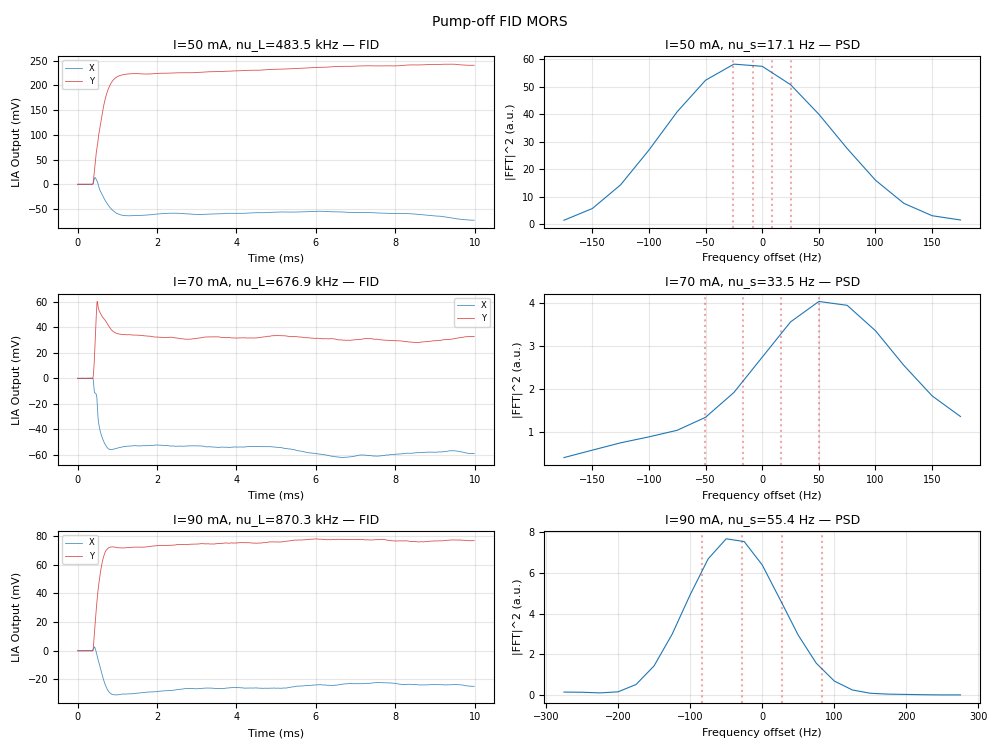

In [26]:
# =====================================================================
# 可视化: 时域 FID + 频域 PSD
# =====================================================================

plt.close('all')
_rc = {k: plt.rcParams[k] for k in ['font.size','axes.titlesize','axes.labelsize',
                                     'xtick.labelsize','ytick.labelsize','legend.fontsize']}
plt.rcParams.update({'font.size':8,'axes.titlesize':9,'axes.labelsize':8,
                     'xtick.labelsize':7,'ytick.labelsize':7,'legend.fontsize':6})

n_plots = len(all_results)
if n_plots > 0:
    fig, axes = plt.subplots(n_plots, 2, figsize=(10, 2.5*n_plots))
    if n_plots == 1:
        axes = np.array([axes])

    for i, res in enumerate(all_results):
        I = res["I_mA"]
        nu_L = res["nu_L_theory_Hz"]
        nu_s_theory = nu_L**2 / (2 * NU_HFS)

        t = res["time"] * 1000  # ms
        x_mean = np.nanmean(res["x_waveforms"], axis=0)
        y_mean = np.nanmean(res["y_waveforms"], axis=0)

        # 时域
        ax_t = axes[i, 0]
        ax_t.plot(t, x_mean*1e3, 'C0', lw=0.6, alpha=0.8, label='X')
        ax_t.plot(t, y_mean*1e3, 'C3', lw=0.6, alpha=0.8, label='Y')
        ax_t.set_xlabel('Time (ms)')
        ax_t.set_ylabel('LIA Output (mV)')
        ax_t.set_title(f'I={I:.0f} mA, nu_L={nu_L/1000:.1f} kHz — FID')
        ax_t.legend()
        ax_t.grid(True, alpha=0.3)

        # 频域
        freqs, psd, _, _, _ = analyze_fid(t/1000, res["x_waveforms"], res["y_waveforms"],
                                           nu_s_theory, nu_L)
        ax_f = axes[i, 1]
        ax_f.plot(freqs, psd, 'C0-', lw=0.8)
        # 标注预期峰位置
        for m_shift in [-1.5, -0.5, 0.5, 1.5]:
            ax_f.axvline(m_shift * nu_s_theory, color='C3', ls=':', alpha=0.4)
        ax_f.set_xlabel('Frequency offset (Hz)')
        ax_f.set_ylabel('|FFT|^2 (a.u.)')
        ax_f.set_title(f'I={I:.0f} mA, nu_s={nu_s_theory:.1f} Hz — PSD')
        ax_f.grid(True, alpha=0.3)

    fig.suptitle('Pump-off FID MORS', fontsize=10)
    fig.tight_layout()
    fig.savefig(results_dir / "pump_off_fid_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()

plt.rcParams.update(_rc)

In [27]:
# ========== 安全断开 ==========

print("Disconnecting...")
try:
    gs.set_current(B_CURRENT_mA[0] / 1000.0)
    print(f"  B field restored: {B_CURRENT_mA[0]} mA")
except Exception as e:
    print(f"  B field restore failed: {e}")

for name, dev in devices.items():
    if hasattr(dev, "disconnect"):
        try:
            dev.disconnect()
            print(f"  {name} disconnected")
        except Exception as e:
            print(f"  {name} failed: {e}")

print("All done")

Disconnecting...
  B field restored: 50.0 mA
  gs200 disconnected
  dg_laser disconnected
  dg_mod disconnected
  dg_temp disconnected
  tec disconnected
  hf2 disconnected
All done
